<a href="https://colab.research.google.com/github/danangcorp/Fraud-Analytics-Dashboard/blob/main/Analisis_dan_Visualisasi_Deteksi_Penipuan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

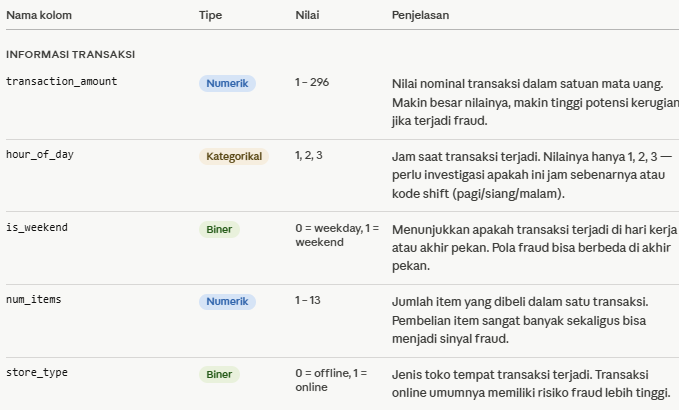
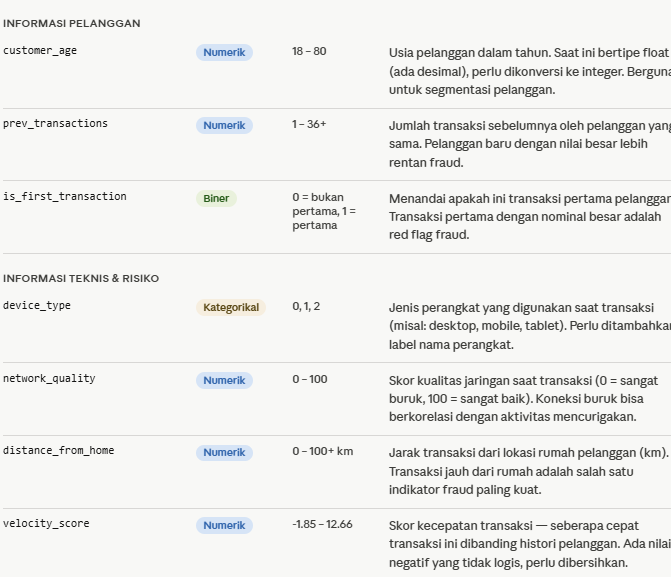
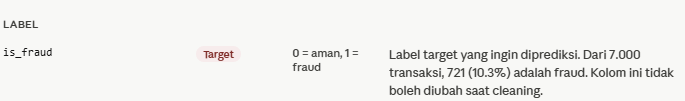

#Step 1 Import Library & Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("Library siap!")

Library siap!


In [ ]:
# STEP 1.2 - Load & Inspect Data

df = pd.read_csv('fraud.csv')

print("Shape :", df.shape)
print()
print(df.head())
print()
df.info()

Shape : (7000, 13)

   transaction_amount  hour_of_day  is_weekend  num_items  customer_age  \
0          161.363691          3.0         0.0        2.0     18.000000   
1          116.202851          1.0         1.0        4.0     26.285818   
2            1.000000          2.0         0.0        5.0     18.000000   
3           48.780618          2.0         0.0        3.0     44.471190   
4                 NaN          3.0         0.0        4.0     38.733609   

   prev_transactions  distance_from_home  device_type  network_quality  \
0                2.0           26.539742          1.0        48.403937   
1                2.0           50.714402          NaN        76.144979   
2                NaN            9.467935          0.0        67.600316   
3                NaN           41.077068          0.0        94.825526   
4                8.0                 NaN          2.0       100.000000   

   is_first_transaction  store_type  velocity_score  is_fraud  
0                   

In [ ]:
# STEP 1.3 - Statistik Awal

print(df.describe().round(2))

       transaction_amount  hour_of_day  is_weekend  num_items  customer_age  \
count             6440.00      6650.00     6860.00    6790.00       6160.00   
mean               100.01         2.20        0.11       2.98         36.20   
std                 49.09         0.68        0.31       1.71         13.28   
min                  1.00         1.00        0.00       0.00         18.00   
25%                 65.71         2.00        0.00       2.00         25.24   
50%                 99.48         2.00        0.00       3.00         35.36   
75%                132.90         3.00        0.00       4.00         45.50   
max                296.31         3.00        1.00      13.00         80.00   

       prev_transactions  distance_from_home  device_type  network_quality  \
count            6510.00             6300.00      6720.00          6370.00   
mean                4.46               24.83         0.70            74.09   
std                 4.88               24.31         0

 #Step 2 — Cek Missing Values

In [ ]:
# STEP 2.1 - Cek Missing Values

total    = df.isnull().sum()
persen   = (df.isnull().sum() / len(df) * 100).round(2)

missing = pd.DataFrame({'Total Missing': total, 'Persen (%)': persen})
print(missing[missing['Total Missing'] > 0])

                      Total Missing  Persen (%)
transaction_amount              560         8.0
hour_of_day                     350         5.0
is_weekend                      140         2.0
num_items                       210         3.0
customer_age                    840        12.0
prev_transactions               490         7.0
distance_from_home              700        10.0
device_type                     280         4.0
network_quality                 630         9.0
is_first_transaction            210         3.0
store_type                      140         2.0
velocity_score                 1050        15.0


In [ ]:
# STEP 2.2 - Fix Warning (pandas 3.0 compatible)

# Kolom numerik → median
num_cols = ['transaction_amount', 'customer_age', 'prev_transactions',
            'distance_from_home', 'network_quality', 'velocity_score']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Kolom kategorikal/biner → mode
cat_cols = ['hour_of_day', 'is_weekend', 'num_items',
            'device_type', 'is_first_transaction', 'store_type']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values:", df.isnull().sum().sum())

Missing values: 0


In [ ]:
# STEP 3 - Cek Duplikat

print("Jumlah duplikat:", df.duplicated().sum())

Jumlah duplikat: 0


In [ ]:
# STEP 4.1 - Deteksi Outlier dengan IQR

num_cols = ['transaction_amount', 'customer_age', 'prev_transactions',
            'distance_from_home', 'network_quality', 'velocity_score']

for col in num_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"{col:25} lower={lower:.2f}  upper={upper:.2f}  outlier={outlier}")

transaction_amount        lower=-21.05  upper=219.58  outlier=62
customer_age              lower=1.44  upper=69.26  outlier=59
prev_transactions         lower=-6.50  upper=13.50  outlier=367
distance_from_home        lower=-27.53  upper=68.23  outlier=385
network_quality           lower=27.06  upper=122.80  outlier=49
velocity_score            lower=0.73  upper=9.28  outlier=209


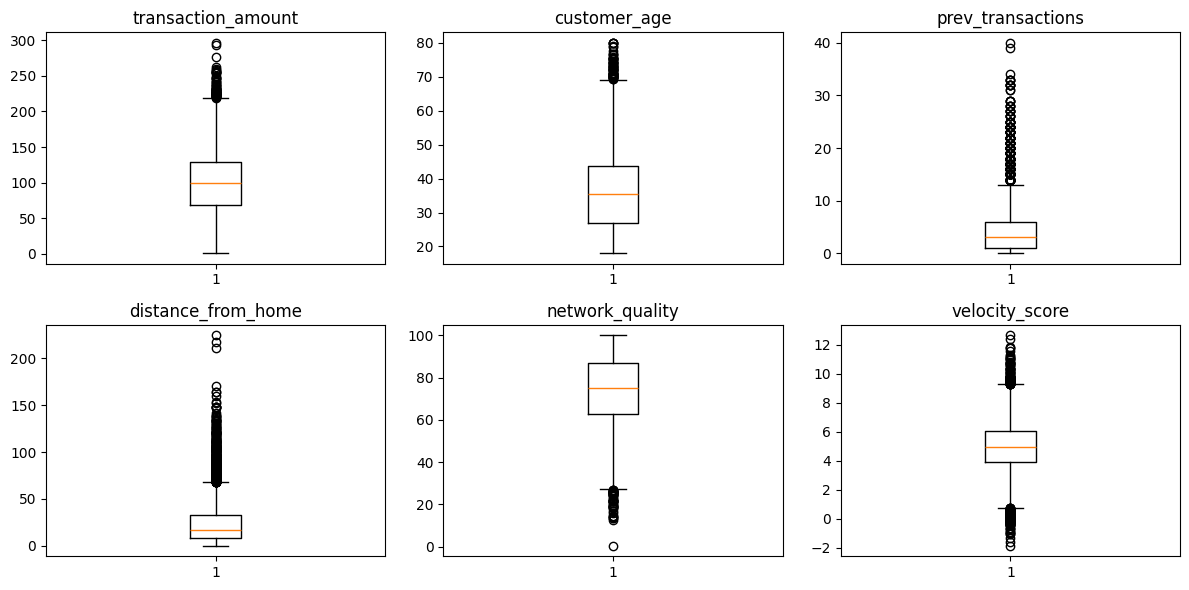

In [ ]:
# STEP 4.1 - Deteksi Outlier dengan Boxplot

num_cols = ['transaction_amount', 'customer_age', 'prev_transactions',
            'distance_from_home', 'network_quality', 'velocity_score']

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [ ]:
# STEP 4.2 - Tangani Outlier

# Cap outlier dengan batas IQR
cap_cols = ['transaction_amount', 'prev_transactions', 'distance_from_home']

for col in cap_cols:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(upper=upper)

# velocity_score tidak boleh negatif → clip ke 0
df['velocity_score'] = df['velocity_score'].clip(lower=0)

print("Outlier selesai ditangani!")
print(df[cap_cols + ['velocity_score']].describe().round(2))

Outlier selesai ditangani!
       transaction_amount  prev_transactions  distance_from_home  \
count             7000.00            7000.00             7000.00   
mean                99.82               4.09               22.77   
std                 46.64               3.87               18.88   
min                  1.00               0.00                0.00   
25%                 69.19               1.00                8.38   
50%                 99.48               3.00               17.32   
75%                129.35               6.00               32.32   
max                219.58              13.50               68.23   

       velocity_score  
count         7000.00  
mean             5.01  
std              1.84  
min              0.00  
25%              3.94  
50%              4.99  
75%              6.08  
max             12.66  


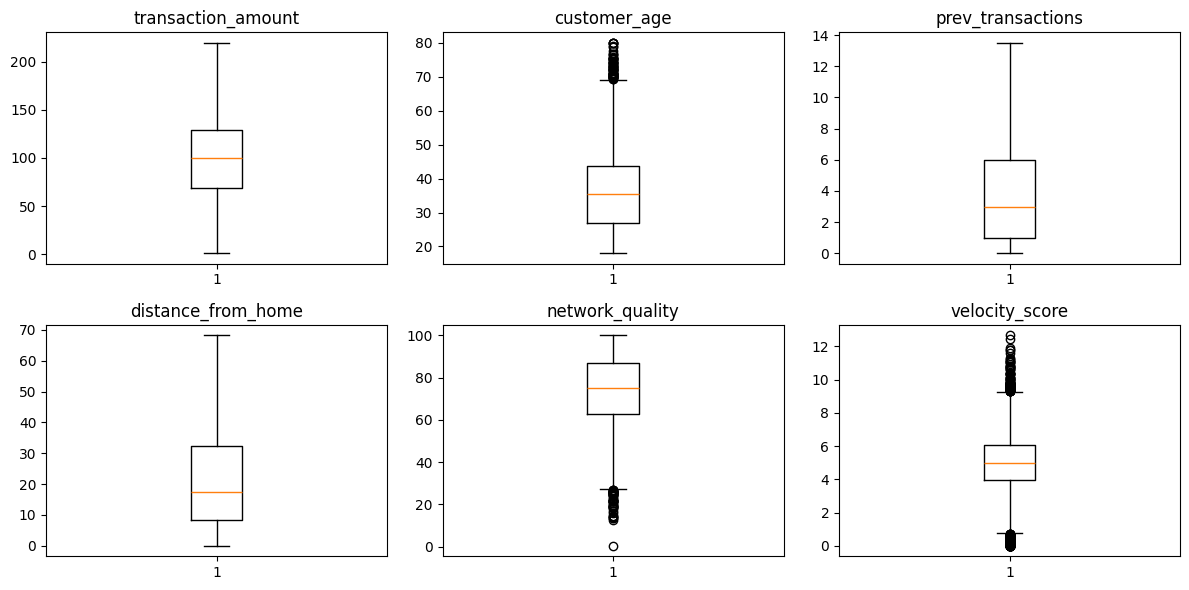

In [ ]:
# STEP 4.3 - Boxplot Setelah Outlier Ditangani

num_cols = ['transaction_amount', 'customer_age', 'prev_transactions',
            'distance_from_home', 'network_quality', 'velocity_score']

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [ ]:
# STEP 5 - Fix Data Types

int_cols = ['customer_age', 'hour_of_day', 'is_weekend', 'num_items',
            'device_type', 'is_first_transaction', 'store_type', 'prev_transactions']

for col in int_cols:
    df[col] = df[col].astype(int)

print(df.dtypes)

transaction_amount      float64
hour_of_day               int64
is_weekend                int64
num_items                 int64
customer_age              int64
prev_transactions         int64
distance_from_home      float64
device_type               int64
network_quality         float64
is_first_transaction      int64
store_type                int64
velocity_score          float64
is_fraud                  int64
dtype: object


In [ ]:
# STEP 6 - Final Check & Export

# Cek akhir
print("Missing values :", df.isnull().sum().sum())
print("Duplikat       :", df.duplicated().sum())
print("Shape          :", df.shape)
print()
print(df.describe().round(2))


Missing values : 0
Duplikat       : 0
Shape          : (7000, 13)

       transaction_amount  hour_of_day  is_weekend  num_items  customer_age  \
count             7000.00      7000.00     7000.00    7000.00       7000.00   
mean                99.82         2.19        0.11       2.98         35.67   
std                 46.64         0.66        0.31       1.69         12.39   
min                  1.00         1.00        0.00       0.00         18.00   
25%                 69.19         2.00        0.00       2.00         26.00   
50%                 99.48         2.00        0.00       3.00         35.00   
75%                129.35         3.00        0.00       4.00         43.00   
max                219.58         3.00        1.00      13.00         80.00   

       prev_transactions  distance_from_home  device_type  network_quality  \
count            7000.00             7000.00      7000.00          7000.00   
mean                4.07               22.77         0.67        

EDA 1 — Distribusi Fraud vs Non-Fraud.

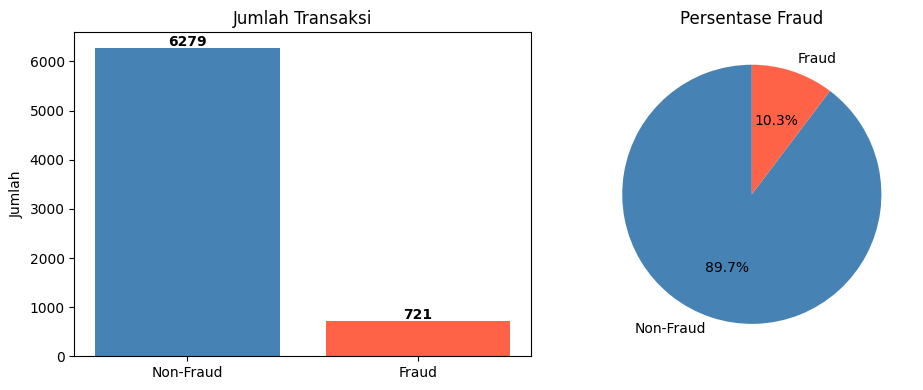

In [ ]:
# EDA 1 - Distribusi Fraud vs Non-Fraud

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
fraud_count = df['is_fraud'].value_counts()
axes[0].bar(['Non-Fraud', 'Fraud'], fraud_count.values, color=['steelblue', 'tomato'])
axes[0].set_title('Jumlah Transaksi')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(fraud_count.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(fraud_count.values, labels=['Non-Fraud', 'Fraud'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Persentase Fraud')

plt.tight_layout()
plt.show()

EDA 2 — Distribusi Transaction Amount.

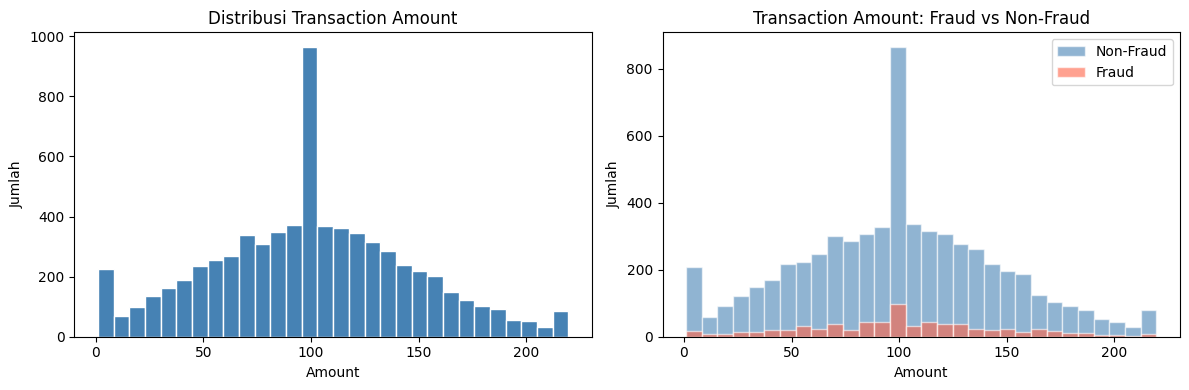

In [ ]:
# EDA 2 - Distribusi Transaction Amount

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Semua transaksi
axes[0].hist(df['transaction_amount'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Transaction Amount')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Jumlah')

# Fraud vs Non-Fraud
for label, color in zip([0, 1], ['steelblue', 'tomato']):
    subset = df[df['is_fraud'] == label]['transaction_amount']
    axes[1].hist(subset, bins=30, alpha=0.6, color=color,
                 edgecolor='white', label=['Non-Fraud', 'Fraud'][label])
axes[1].set_title('Transaction Amount: Fraud vs Non-Fraud')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Jumlah')
axes[1].legend()

plt.tight_layout()
plt.show()

EDA 3 — Fraud berdasarkan Jam

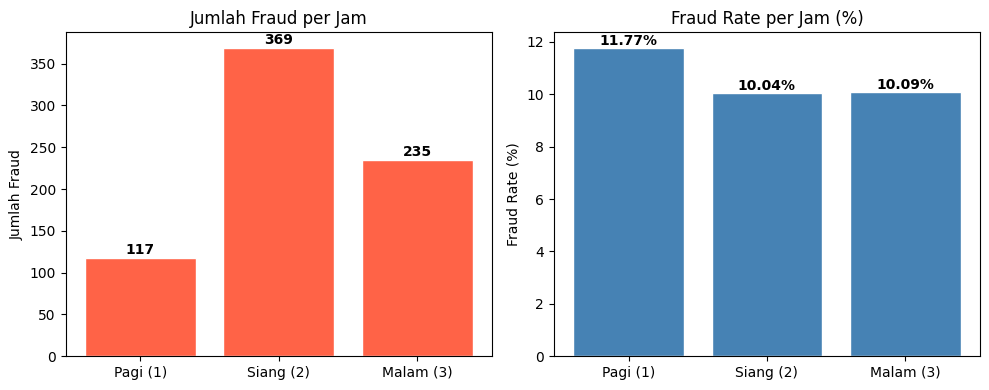

In [ ]:
# EDA 3 - Fraud berdasarkan Hour of Day

fraud_hour = df.groupby('hour_of_day')['is_fraud'].agg(['sum', 'count'])
fraud_hour['rate'] = (fraud_hour['sum'] / fraud_hour['count'] * 100).round(2)
fraud_hour.index = ['Pagi (1)', 'Siang (2)', 'Malam (3)']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Jumlah fraud
axes[0].bar(fraud_hour.index, fraud_hour['sum'], color='tomato', edgecolor='white')
axes[0].set_title('Jumlah Fraud per Jam')
axes[0].set_ylabel('Jumlah Fraud')
for i, v in enumerate(fraud_hour['sum']):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Fraud rate
axes[1].bar(fraud_hour.index, fraud_hour['rate'], color='steelblue', edgecolor='white')
axes[1].set_title('Fraud Rate per Jam (%)')
axes[1].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(fraud_hour['rate']):
    axes[1].text(i, v + 0.1, f'{v}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

EDA 4 — Fraud berdasarkan Weekend vs Weekday

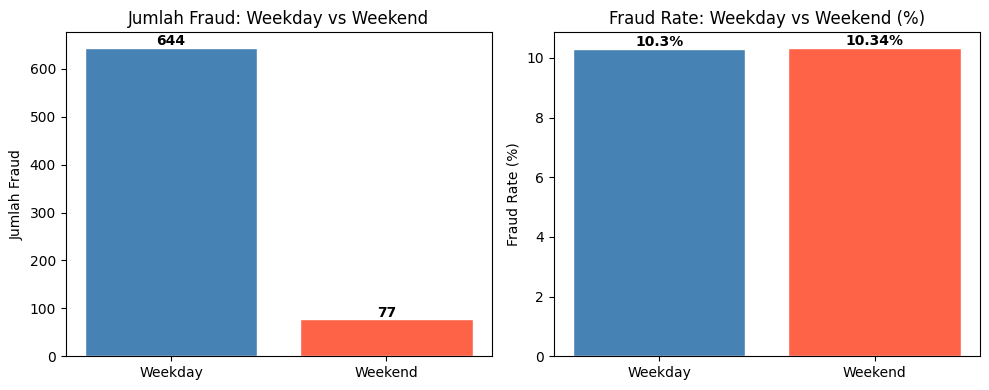

In [ ]:
# EDA 4 - Fraud berdasarkan Weekend vs Weekday

fraud_weekend = df.groupby('is_weekend')['is_fraud'].agg(['sum', 'count'])
fraud_weekend['rate'] = (fraud_weekend['sum'] / fraud_weekend['count'] * 100).round(2)
fraud_weekend.index = ['Weekday', 'Weekend']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Jumlah fraud
axes[0].bar(fraud_weekend.index, fraud_weekend['sum'],
            color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Jumlah Fraud: Weekday vs Weekend')
axes[0].set_ylabel('Jumlah Fraud')
for i, v in enumerate(fraud_weekend['sum']):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Fraud rate
axes[1].bar(fraud_weekend.index, fraud_weekend['rate'],
            color=['steelblue', 'tomato'], edgecolor='white')
axes[1].set_title('Fraud Rate: Weekday vs Weekend (%)')
axes[1].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(fraud_weekend['rate']):
    axes[1].text(i, v + 0.1, f'{v}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Export ulang khusus untuk Power BI Indonesia
df.to_csv('clean_fraud_powerbi.csv',
          index=False,
          sep=',',
          decimal='.',
          float_format='%.2f')

print("Done!")
print(df[['distance_from_home', 'transaction_amount']].head())

Done!
   distance_from_home  transaction_amount
0               26.54              161.36
1               50.71              116.20
2                9.47                1.00
3               41.08               48.78
4               17.32               99.48


In [ ]:
df = pd.read_csv('clean_fraud_powerbi.csv')
df.head()

,transaction_amount,hour_of_day,is_weekend,num_items,customer_age,prev_transactions,distance_from_home,device_type,network_quality,is_first_transaction,store_type,velocity_score,is_fraud
0,161.36,3,0,2,18,2,26.54,1,48.40,0,0,3.72,0
1,116.20,1,1,4,26,2,50.71,0,76.14,0,0,4.95,0
2,1.00,2,0,5,18,3,9.47,0,67.60,0,0,4.56,0
3,48.78,2,0,3,44,3,41.08,0,94.83,0,0,6.92,0
4,99.48,3,0,4,38,8,17.32,2,100.00,0,1,5.54,1


In [ ]:
# Pisahkan kolom integer dan float
int_cols   = ['hour_of_day', 'is_weekend', 'num_items', 'customer_age',
              'prev_transactions', 'device_type', 'is_first_transaction',
              'store_type', 'is_fraud']

float_cols = ['transaction_amount', 'distance_from_home',
              'network_quality', 'velocity_score']

# Pastikan tipe data benar
for col in int_cols:
    df[col] = df[col].astype(int)
for col in float_cols:
    df[col] = df[col].astype(float).round(2)

# Export dengan desimal koma (format Indonesia)
df.to_csv('clean_fraud_powerbi.csv',
          index=False,
          sep=';',          # separator titik koma
          decimal=',')      # desimal pakai koma

print("File siap!")
print(df.head(3))

File siap!
   transaction_amount  hour_of_day  is_weekend  num_items  customer_age  \
0              161.36            3           0          2            18   
1              116.20            1           1          4            26   
2                1.00            2           0          5            18   

   prev_transactions  distance_from_home  device_type  network_quality  \
0                  2               26.54            1            48.40   
1                  2               50.71            0            76.14   
2                  3                9.47            0            67.60   

   is_first_transaction  store_type  velocity_score  is_fraud  
0                     0           0            3.72         0  
1                     0           0            4.95         0  
2                     0           0            4.56         0  


In [ ]:
df_1 = pd.read_csv('/content/clean_fraud_powerbi.csv')
df_1.head()# Cek tipe data dulu
print(df_1.dtypes)
print()
print(df_1.head(3))

transaction_amount;hour_of_day;is_weekend;num_items;customer_age;prev_transactions;distance_from_home;device_type;network_quality;is_first_transaction;store_type;velocity_score;is_fraud    object
dtype: object

                                      transaction_amount;hour_of_day;is_weekend;num_items;customer_age;prev_transactions;distance_from_home;device_type;network_quality;is_first_transaction;store_type;velocity_score;is_fraud
161 36;3;0;2;18;2;26 54;1;48 4;0;0;3                                                72;0                                                                                                                                       
116 2;1;1;4;26;2;50  71;0;76 14;0;0;4                                               95;0                                                                                                                                       
1   0;2;0;5;18;3;9   47;0;67 6;0;0;4                                                56;0                             

In [ ]:
# Cek tipe data dulu
print(df.dtypes)
print()
print(df.head(3))